# Duplicate CA Cities


We are in the process of making CA city boundaries available in climaitae, and noticed that there are duplicate city names in the [input boundary dataset](https://data.ca.gov/dataset/california-city-boundaries-and-identifiers).  This notebook explores these repeat entries, to inform how we decide to handle them.

## Step 0: Set-Up
Import the [climakitae](https://github.com/cal-adapt/climakitae) library and other dependencies.

In [ ]:
import climakitae as ck

from climakitae.core.data_load import load

import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from climakitae.new_core.data_access.boundaries import Boundaries
import intake
import contextily as cx
import pandas as pd
from shapely.geometry import Point, LineString, Polygon
import matplotlib.cm as cm
import matplotlib.colors as mcolors

### Step 1: Load in city boundaries

In [ ]:
catalog = intake.open_catalog('boundaries.yaml')
boundaries = Boundaries(catalog)
# Get all boundary options for UI population
boundary_options = boundaries.boundary_dict()

In [ ]:
# Access specific boundary data (loaded lazily)
ca_cities = boundaries._ca_cities
ca_counties= boundaries._ca_counties

### Step 2: Let's take a look at these duplicates

How many duplicates are there?

In [ ]:
# just establishing that there are no duplicate counties
ca_counties["NAME"].duplicated().sum()

In [ ]:
ca_cities["CDT_NAME_S"].duplicated().sum()

A good number of them. Where are they located? My hypothesis is that these are coastal cities, split into their land- and water-bound components.

In [46]:
# store a subset of only duplicate cities
duplicate_cities = ca_cities[ca_cities.duplicated(subset=["CENSUS_GEO"], keep=False)]

In [ ]:
# the "OFFSHORE" variable indicates whether or not the city is offshore
ca_cities["OFFSHORE"].unique()

In [ ]:
# now construct a dataframe of city names and whether or not AT LEAST 1 component is offshore (ie, "OFFSHORE" not None, so either "bay" or "ocean"), 
# as well as how many duplicates there in each subset
data = []
for name in duplicate_cities["CDT_NAME_S"].unique():
    subset = duplicate_cities[duplicate_cities["CDT_NAME_S"] == name]
    offshore_bool = subset["OFFSHORE"].notna().any()
    data.append({"CDT_NAME_S":name, "offshore_component": offshore_bool, "num_components": len(subset)})
data_df = pd.DataFrame(data)

In [ ]:
# divide the total number of unique duplicate cities by how many contain at least one water-bound component (ie, "OFFSHORE" is not None)
perc_offshore_dups = sum(data_df["offshore_component"]) / len(duplicate_cities['CENSUS_GEO'].unique()) * 100
perc_offshore_dups

As expected, all duplicate contain at least one offshore component. We should then expect that each subset would contain 2-3 components - one inland, one offshore and either in a bay or in the ocean.

In [ ]:
data_df['num_components'].unique()

In [ ]:
data_df[data_df["num_components"]==3]

In [ ]:
duplicate_cities[duplicate_cities["CDT_NAME_S"] == "San Francisco"]

Indeed, there are either 2 or 3 components in each subset of duplicates. Only San Fransciso contains 3, as one component is inland, one is ocean-bound, and one is bay-bound.

### Step 3: And now to visualize them

Let's map cities with dupicate entries!

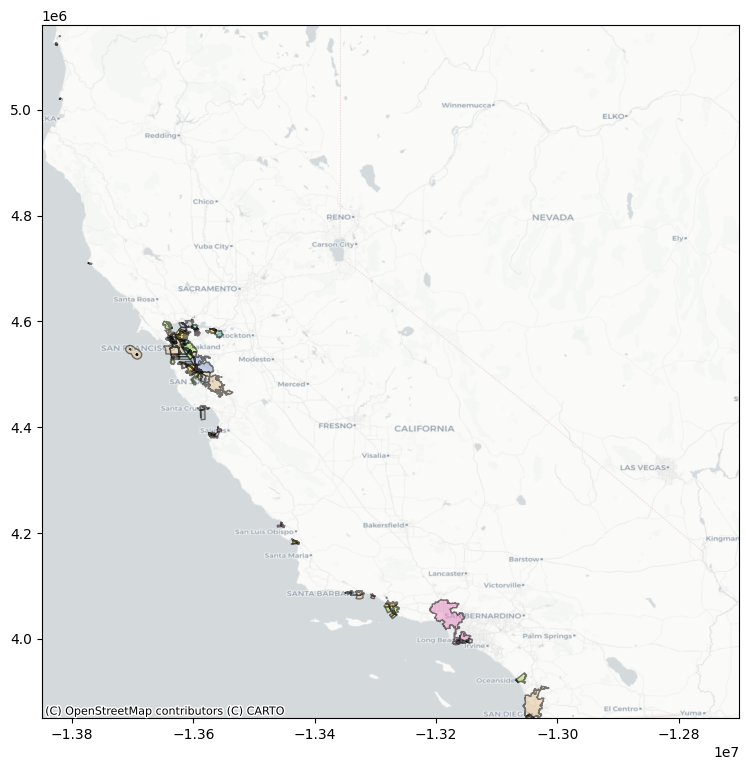

In [49]:
fig, ax = plt.subplots(figsize=(9, 9))

xlim = [-1.385e7, -1.270e7]
ylim = [3.85e6, 5.16e6]
ax.set_ylim(ylim)
ax.set_xlim(xlim)

duplicate_cities = duplicate_cities.to_crs(epsg=3857)

# Build a color map: one color per unique "love" value
categories = duplicate_cities["CENSUS_GEO"].unique()
palette = cm.get_cmap("Set2", len(categories))
color_map = {cat: mcolors.to_hex(palette(i)) for i, cat in enumerate(categories)}

for _, row in duplicate_cities.iterrows():
    geom = row.geometry
    fill_color = color_map[row["CENSUS_GEO"]]

    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, color=fill_color, alpha=0.5, edgecolor="black")
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, color=fill_color, alpha=0.5, edgecolor="black")

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

#### Step 3.1: Visualize individual cities

In [68]:
def map_city(df,city_name, xlim, ylim):
    fig, ax = plt.subplots(figsize=(9, 9))

    ax.set_ylim(ylim)
    ax.set_xlim(xlim)

    city = df[df['CDT_NAME_S']==city_name]

    # Build a color map: one color per unique OFFSHORE value
    color_map = {
        None: {"color": "orange", "weight": 0.1},
        "ocean": {"color": "cyan", "weight": 0.5},
        "bay": {"color": "purple", "weight": 0.5}
    }

    for _, row in city.iterrows():
        geom = row.geometry
        offshore = row['OFFSHORE']
        fill_color = color_map[offshore]['color']
        alpha_val = color_map[offshore]['weight']
        if offshore is None:
            offshore_type = "None"
        else:
            offshore_type = offshore

        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, color=fill_color, alpha=alpha_val, edgecolor=fill_color,label=offshore_type)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(
                    x,
                    y,
                    color=fill_color,
                    alpha=alpha_val,
                    edgecolor=fill_color,
                    label=offshore_type,
                )

    # Add basemap
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # keeps last handle per unique label
    ax.legend(by_label.values(), by_label.keys())

Take a closer look at Los Angeles. Indeed, one entry is for offshore components of LA, while the other is for inland components.

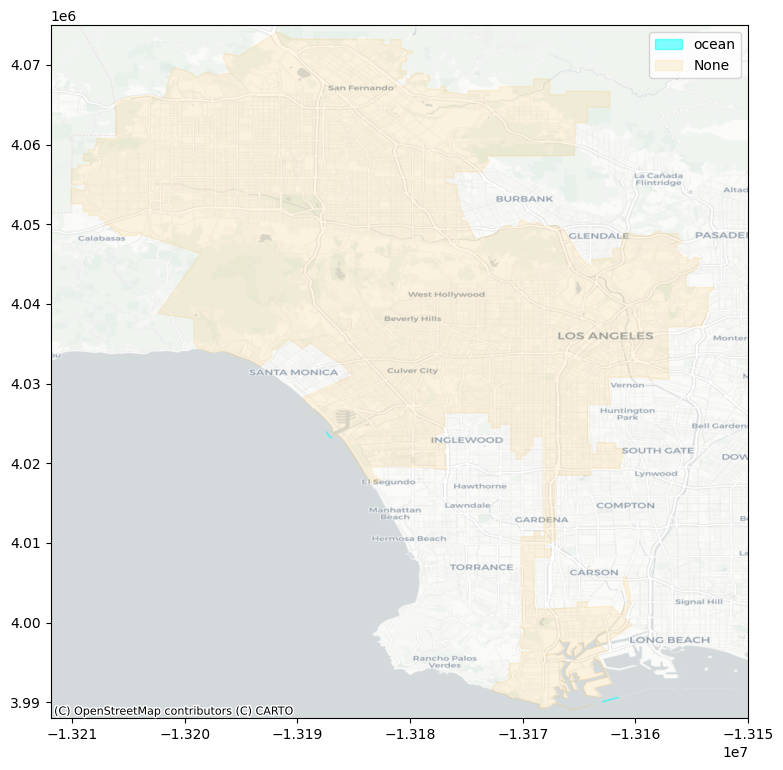

In [70]:
city_name = "Los Angeles"
xlim = [-1.32119e7, -1.315e7]  # lon
ylim = [3.988e6, 4.075e6]  # lat
map_city(duplicate_cities, city_name,xlim, ylim)

It's a little hard to see, but there are two offshore components in cyan near Long Beach and Culver City. These are actually sea walls! Which becomes more apparent upon zooming to one piece, and also taking at satellite imagery.

In [ ]:
city_name = "Los Angeles"
xlim = [-1.317e7, -1.316e7]  # lon
ylim = [3.988e6, 4.0e6]  # lat
map_city(duplicate_cities, city_name, xlim, ylim)

Now let's check out San Francisco, with its "ocean" and "bay" offshore components.

In [ ]:
city_name = "San Francisco"
xlim = [-1.372e7, -1.361e7]  # lon
ylim = [4.5e6, 4.58e6]  # lat
map_city(duplicate_cities, city_name, xlim, ylim)

The "ocean" component comprises the Farallon Island, and SF jurisdiction into the water themselves (ie some distance around the islands and off the mainland shore). Similarly for the "bay" component, which comprises some portion of the  San Fracisco Bay.

Now to check out Santa Cruz, for good measure.

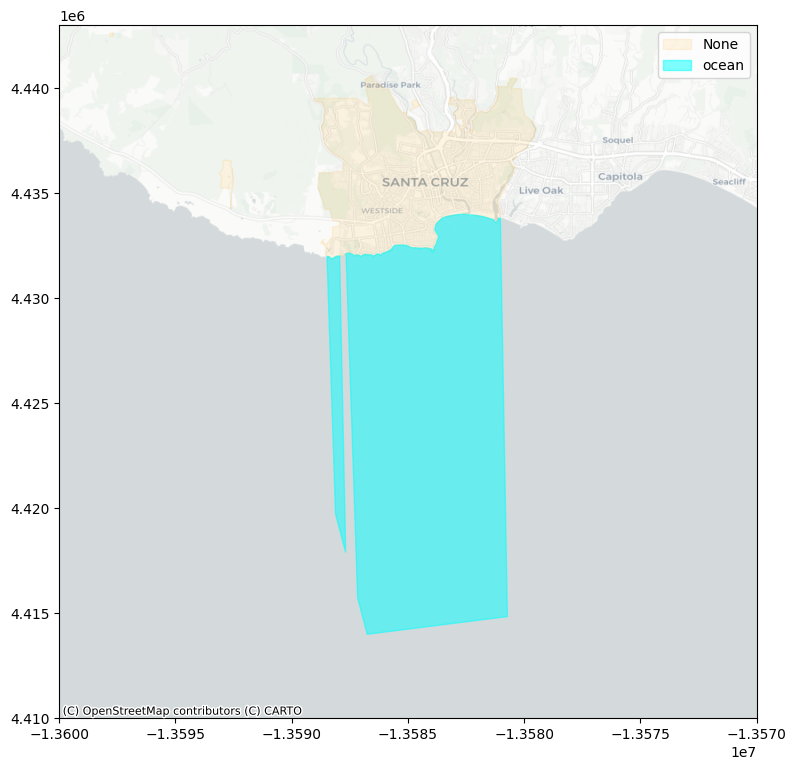

In [73]:
city_name = "Santa Cruz"
xlim = [-1.36e7, -1.357e7]  # lon
ylim = [4.41e6, 4.443e6]  # lat
map_city(duplicate_cities, city_name, xlim, ylim)

Similar to San Francisco, the "ocean" component comprises Santa Cruz jurisdiction extendnig off its coast.

### Step 4: With coastal buffer or without? 

In [41]:
def map_county(name):
    fig, ax = plt.subplots(figsize=(9, 9))

    county = ca_counties[ca_counties["NAME"] == name]
    geom = county.geometry.iloc[0]

    minx, miny, maxx, maxy = geom.bounds
    pad = 0.1
    xlim = (minx - pad, maxx + pad)
    ylim = (miny - pad, maxy + pad)

    ax.set_ylim(ylim)
    ax.set_xlim(xlim)

    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(
            x,
            y,
            color='red',
            alpha=0.2,
            edgecolor='red',
        )
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(
                x,
                y,
                color='red',
                alpha=0.2,
                edgecolor='red',
            )

    # Add basemap
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=ca_counties.crs)

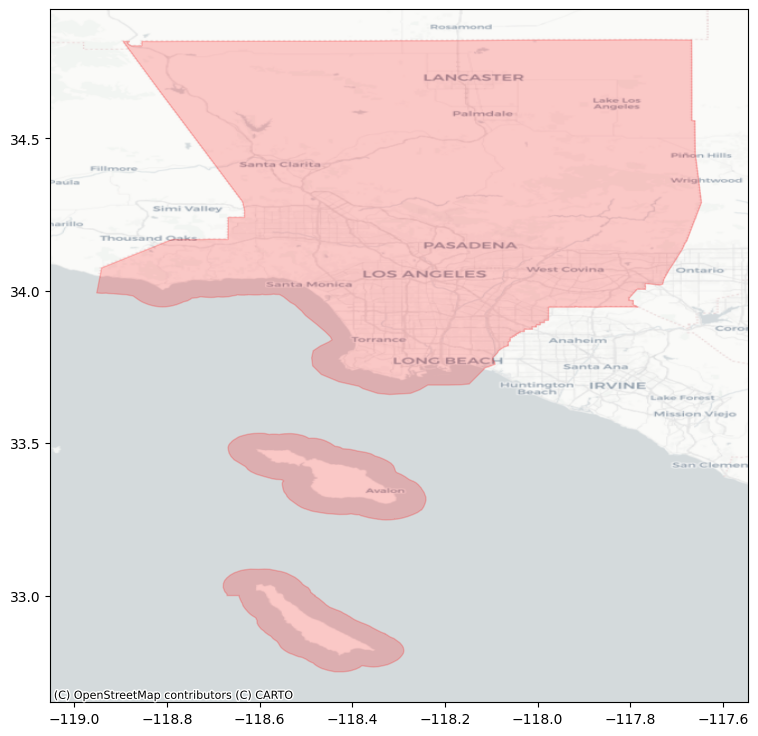

In [42]:
name = "Los Angeles County"
map_county(name)

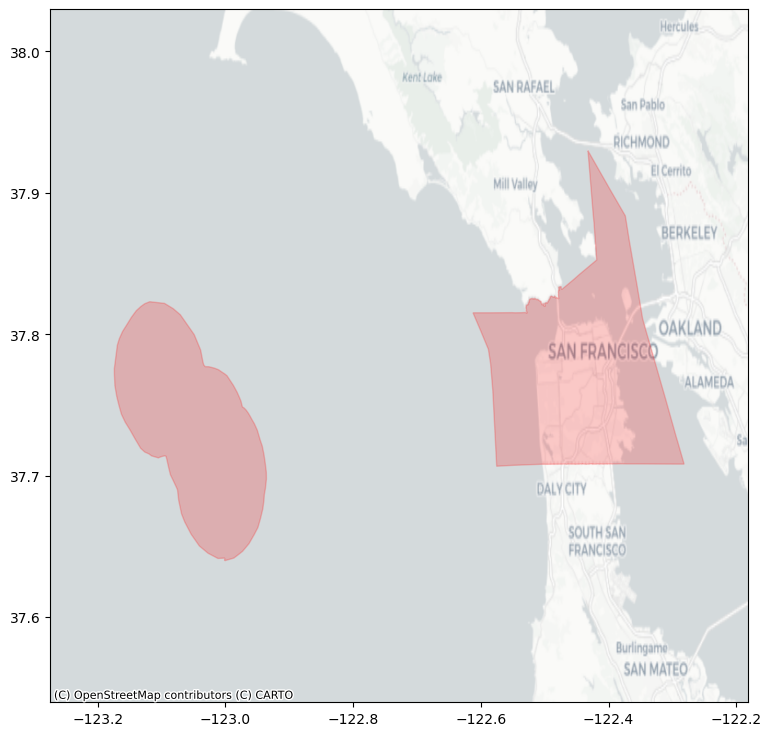

In [44]:
name = "San Francisco County"
map_county(name)

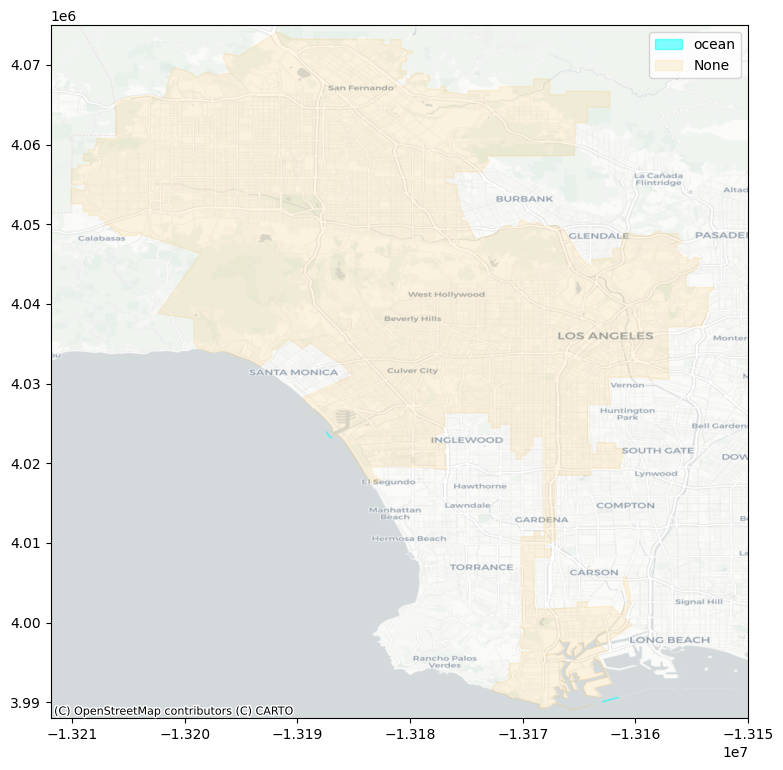

In [71]:
city_name = "Los Angeles"
xlim = [-1.32119e7, -1.315e7]  # lon
ylim = [3.988e6, 4.075e6]  # lat
map_city(duplicate_cities, city_name, xlim, ylim)

In [67]:
ca_cities_buffers = gpd.read_file(
    "California_City_Boundaries_and_Identifiers_with_Coastal_Buffers_3529542519249986974.zip"
)
ca_cities_buffers = ca_cities_buffers.to_crs(epsg=3857)

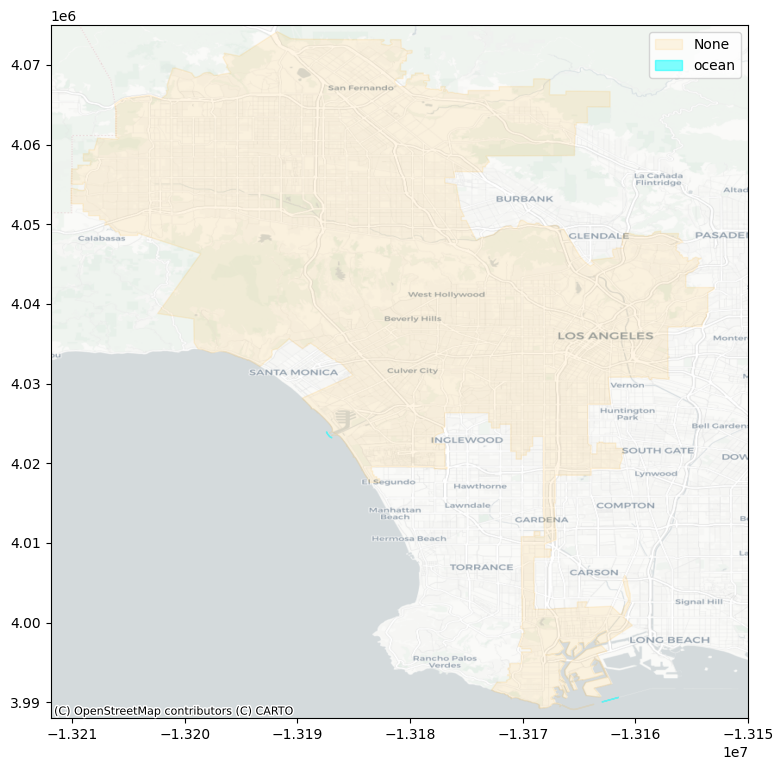

In [72]:
map_city(ca_cities_buffers, city_name, xlim, ylim)

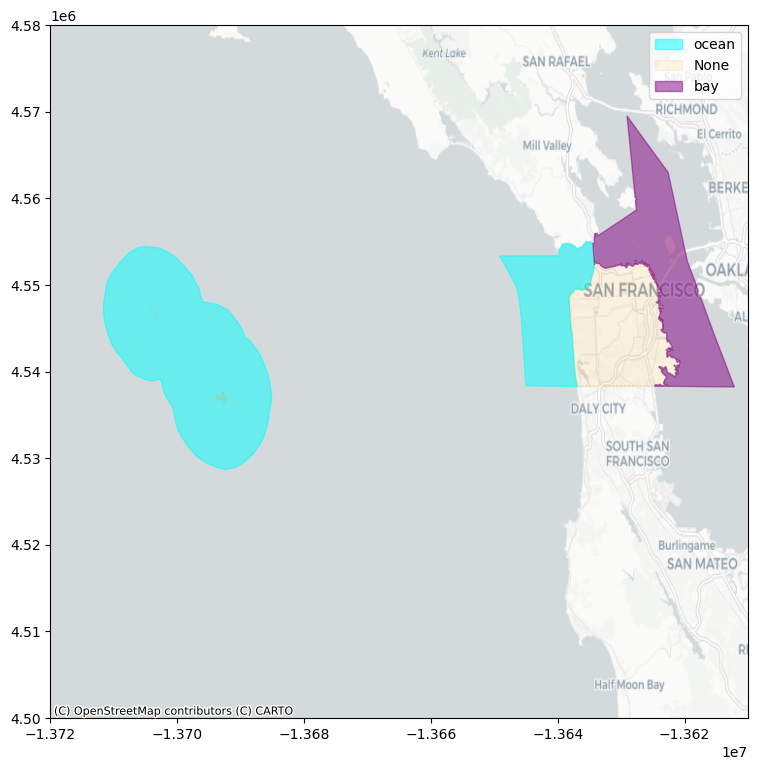

In [74]:
city_name = "San Francisco"
xlim = [-1.372e7, -1.361e7]  # lon
ylim = [4.5e6, 4.58e6]  # lat
map_city(duplicate_cities, city_name, xlim, ylim)

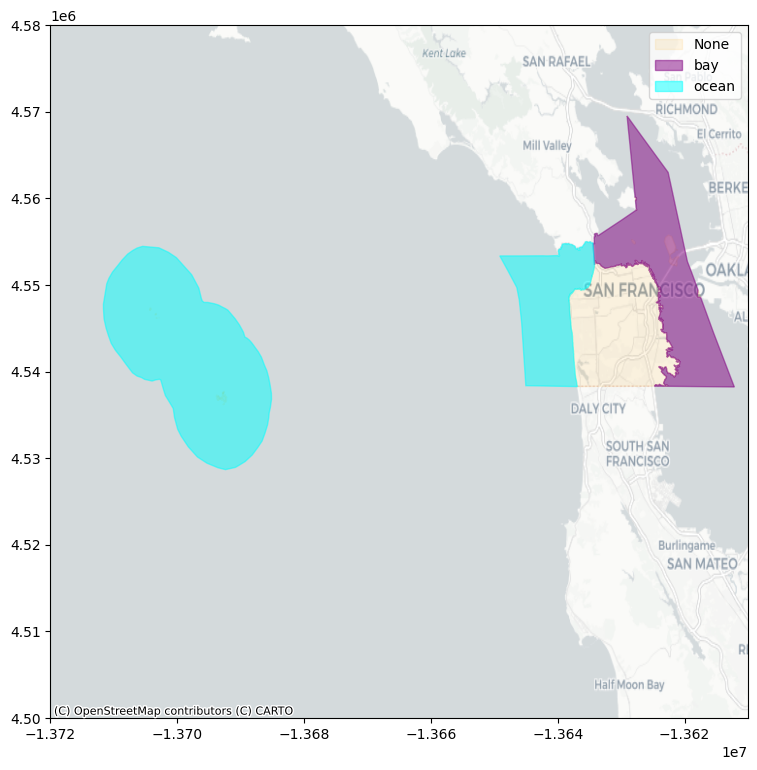

In [75]:
map_city(ca_cities_buffers, city_name, xlim, ylim)

What is the difference between the shapefiles with and without coastal buffers?

In [122]:
la_city_buffers = ca_cities_buffers[ca_cities_buffers["CDTFA_CITY"]=="Los Angeles"]
la_city = ca_cities[ca_cities["CDTFA_CITY"] == "Los Angeles"]

In [123]:
geom_buffers = la_city_buffers.geometry
geom = la_city.geometry

In [ ]:
diff = geom_buffers.difference(geom)


In [130]:
la_city

,CDTFA_COPR,CDTFA_CITY,CDTFA_COUN,CENSUS_PLA,CENSUS_GEO,CENSUS_P_1,GNIS_PLACE,GNIS_ID,CDT_CITY_A,CDT_COUNTY,PRIMARY_DO,CENSUS_POP,CDT_NAME_S,OFFSHORE,AREA_SQMI,GlobalID,geometry
508,19201,Los Angeles,Los Angeles County,Los Angeles,0644000,City,City of Los Angeles,2410877,LANG,LAC,None,0,Los Angeles,ocean,0.011465,f118fa2c-4e62-4848-badb-75383ec86e6a,"MULTIPOLYGON (((142308.412 -449642.805, 142303..."
239,19201,Los Angeles,Los Angeles County,Los Angeles,0644000,City,City of Los Angeles,2410877,LANG,LAC,None,0,Los Angeles,None,473.247396,3306fcab-7997-4918-90f1-c619fea6596f,"MULTIPOLYGON (((162582.153 -470870.003, 162584..."


In [127]:
diff

239    MULTIPOLYGON (((-13163005.64 3997111.289, -131...
508    MULTIPOLYGON (((-13186952.491 4023190.589, -13...
dtype: geometry

In [129]:
def map_diff(city, xlim, ylim):
    fig, ax = plt.subplots(figsize=(9, 9))

    ax.set_ylim(ylim)
    ax.set_xlim(xlim)

    for _, row in city.iterrows():
        geom = row.geometry

        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(
                x,
                y,
                color="red",
                alpha=0.5,
                edgecolor="red",
            )
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(
                    x,
                    y,
                    color="red",
                    alpha=0.5,
                    edgecolor="red",
                )

    # Add basemap
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # keeps last handle per unique label
    ax.legend(by_label.values(), by_label.keys())

In [131]:
import geopandas as gpd
from shapely.ops import unary_union


# Union all rows within each dataset into a single geometry
union1 = unary_union(la_city.geometry)
union2 = unary_union(la_city_buffers.geometry)

# Difference between the two unioned geometries (both directions)
diff_1_not_2 = union1.difference(union2)  # in dataset1 but not dataset2
diff_2_not_1 = union2.difference(union1)  # in dataset2 but not dataset1
sym_diff = union1.symmetric_difference(union2)  # areas that differ either way

# Wrap results back into GeoDataFrames for saving/plotting
diff_gdf = gpd.GeoDataFrame(
    {"label": ["in_1_not_2", "in_2_not_1"]},
    geometry=[diff_1_not_2, diff_2_not_1],
    crs=la_city.crs,
)

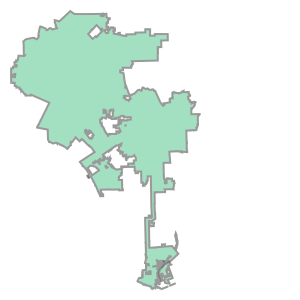

In [139]:
union1

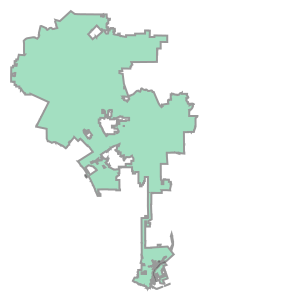

In [140]:
union2

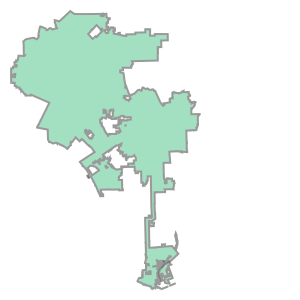

In [141]:
diff_1_not_2

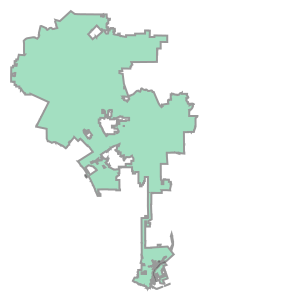

In [142]:
diff_2_not_1